In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import fashion_mnist
import numpy as np
from matplotlib import pyplot as plt

In [2]:
# seed para consistencia
tf.random.set_seed(1)

# confirmando que tem gpu disponivel
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [4]:
# carregando o dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
# juntando os datasets de treino e teste
dataset = np.concatenate([x_train, x_test], axis=0)
# normalizando os dados
dataset = np.expand_dims(dataset, -1).astype("float32") / 255

In [6]:
# definindo um batch size
BATCH_SIZE = 64

# ajustando o formato do dataset para as 3 camadas
dataset = np.reshape(dataset, (-1, 28, 28, 1))
# transformando o dataset em um formato para o tensorflow
dataset = tf.data.Dataset.from_tensor_slices(dataset)
# definindo o batch size
dataset = dataset.shuffle(buffer_size=1024).batch(BATCH_SIZE)

In [9]:
# definindo o tamanho do ruido de entrada
NOISE_DIM = 150

# criando o gerador
generator = keras.models.Sequential([
    keras.layers.InputLayer(input_shape=(NOISE_DIM,)),
    layers.Dense(7*7*256),
    layers.Reshape(target_shape=(7, 7, 256)),

    # tive que alterar a forma de chamar o leakyrelu para funcionar
    layers.Conv2DTranspose(256, 3, activation=tf.keras.layers.LeakyReLU(), strides=2, padding="same"),
    layers.Conv2DTranspose(128, 3, activation=tf.keras.layers.LeakyReLU(), strides=2, padding="same"),
    layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")
])

# sumário do gerador
generator.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 12544)          │     1,894,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_2 (Reshape)             │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 14, 14, 256)    │       590,080 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 28, 28, 128)    │       295,040 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 28, 28, 1)      │         1,153 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,780,417 (10.61 MB)

 Trainable params: 2,780,417 (10.61 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# criando o discriminador
discriminator = keras.models.Sequential([
    # camada de entrada
    keras.layers.InputLayer(input_shape=(28, 28, 1)),
    # convolucao
    layers.Conv2D(256, 3, activation="relu", strides=2, padding="same"),
    layers.Conv2D(128, 3, activation="relu", strides=2, padding="same"),
    layers.Flatten(),
    # camada densa
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(1, activation="sigmoid")
])

# sumario
discriminator.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 256)    │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 128)      │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │       401,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 699,137 (2.67 MB)

 Trainable params: 699,137 (2.67 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# definindo os optimizadores do gerador e do discriminador
optimizerG = keras.optimizers.Adam(learning_rate=0.00001, beta_1=0.5)
optimizerD = keras.optimizers.Adam(learning_rate=0.00003, beta_1=0.5)

# definindo o algoritmo de loss
lossFn = keras.losses.BinaryCrossentropy(from_logits=True)

# métricas de acurácia para cada um
gAccMetric = tf.keras.metrics.BinaryAccuracy()
dAccMetric = tf.keras.metrics.BinaryAccuracy()

In [13]:
# função que fara o treinamento do discriminador
@tf.function
def trainDStep(data):
    # pega o valor do batch size
    batchSize = tf.shape(data)[0]

    # criando um ruído de entrada
    noise = tf.random.normal(shape=(batchSize, NOISE_DIM))

    # juntando os dados reais
    y_true = tf.concat(
        [
            # dados originais
            tf.ones(batchSize, 1),
            # dados falsos
            tf.zeros(batchSize, 1)
        ],
        axis=0
    )

    # gravando para calcular o gradiente depois
    with tf.GradientTape() as tape:
        # gerando dados falsos
        fake = generator(noise)
        # juntando os dados reais com os falsos
        x = tf.concat([data, fake], axis=0)
        # vendo se o discriminador consegue identificar eles
        y_pred = discriminator(x)
        # calcula o loss
        discriminatorLoss = lossFn(y_true, y_pred)

    # backpropagation
    grads = tape.gradient(discriminatorLoss, discriminator.trainable_weights)
    optimizerD.apply_gradients(zip(grads, discriminator.trainable_weights))

    # mostra a acurácia
    dAccMetric.update_state(y_true, y_pred)

    # retorna o histrórico de loss e accuracy
    return {
        "discriminator_loss": discriminatorLoss,
        "discriminator_accuracy": dAccMetric.result()
    }

In [14]:
# função que fara o treinamento do discriminador
@tf.function
def trainGStep(data):
    # pega o batch size
    batchSize = tf.shape(data)[0]
    # cria o ruído de entrada
    noise = tf.random.normal(shape=(batchSize, NOISE_DIM))

    # rotulando os dados reais
    y_true = tf.ones(batchSize, 1)


    with tf.GradientTape() as tape:
        # vendo se o discriminador consegue identificar os dados gerados
        y_pred = discriminator(generator(noise))
        # calculando o loss
        generatorLoss = lossFn(y_true, y_pred)

    # backpropagation
    grads = tape.gradient(generatorLoss, generator.trainable_weights)
    optimizerG.apply_gradients(zip(grads, generator.trainable_weights))

    # mostrando a accuracy
    gAccMetric.update_state(y_true, y_pred)

    # retornando o historico das metricas
    return {
        "generator_loss": generatorLoss,
        "generator_accuracy": gAccMetric.result()
    }

In [16]:
# função para plotar imagens
def plotImages(model):
    images = model(np.random.normal(size=(81, NOISE_DIM)))

    plt.figure(figsize=(9, 9))

    for i, image in enumerate(images):
        plt.subplot(9,9,i+1)
        plt.imshow(np.squeeze(image, -1), cmap="Greys_r")
        plt.axis('off')

    plt.show();

/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/nn.py:1286: UserWarning: "`binary_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Sigmoid activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


E:0, Loss G:2.8311, Loss D:0.1245, Acc G:%0.22, Acc D:%95.26


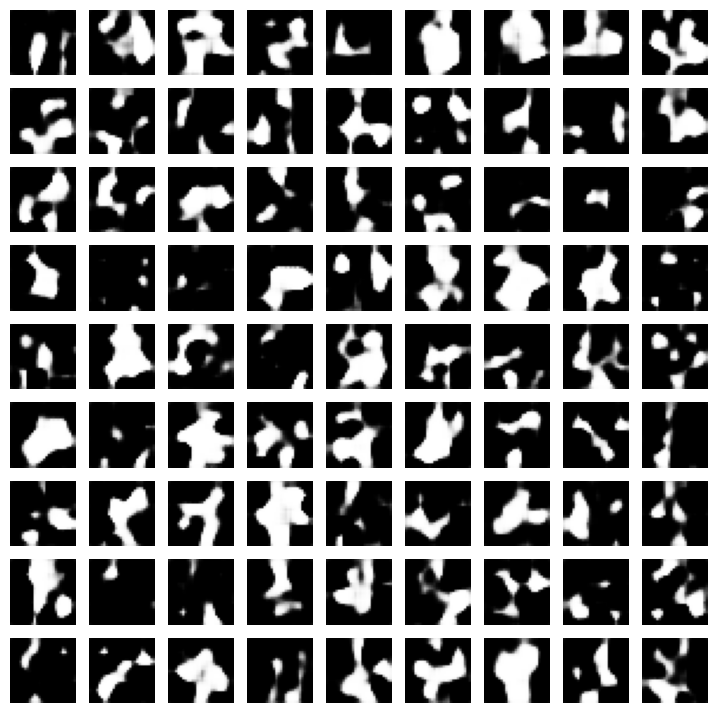

E:1, Loss G:3.1624, Loss D:0.1083, Acc G:%0.48, Acc D:%97.78
E:2, Loss G:3.0277, Loss D:0.1442, Acc G:%1.01, Acc D:%97.19


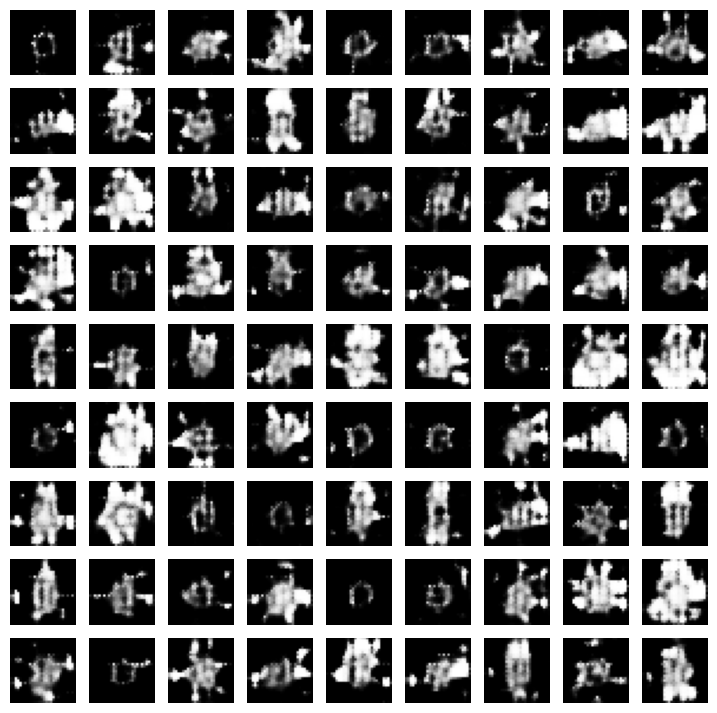

E:3, Loss G:2.5252, Loss D:0.1754, Acc G:%1.38, Acc D:%96.55
E:4, Loss G:2.2345, Loss D:0.2344, Acc G:%1.65, Acc D:%95.91


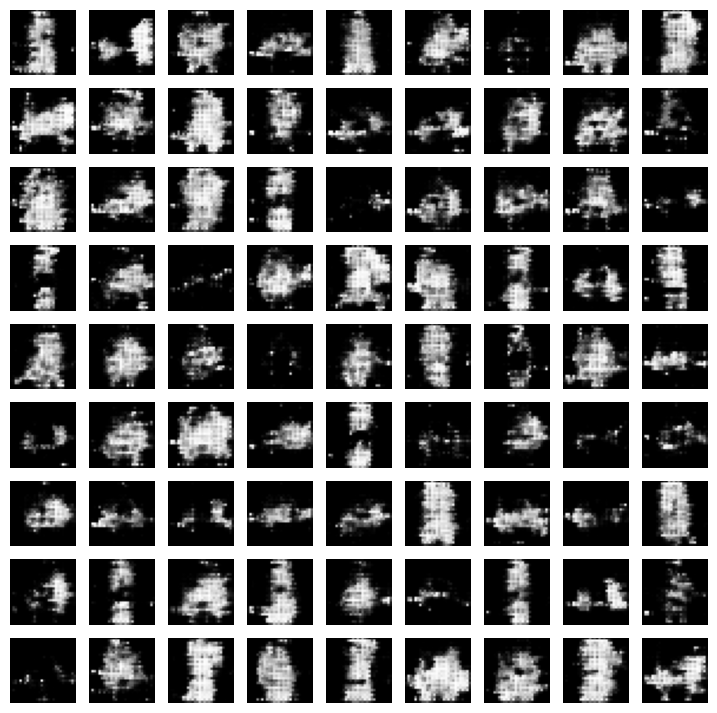

E:5, Loss G:2.0277, Loss D:0.2930, Acc G:%2.40, Acc D:%94.79
E:6, Loss G:1.8461, Loss D:0.3349, Acc G:%3.24, Acc D:%93.70


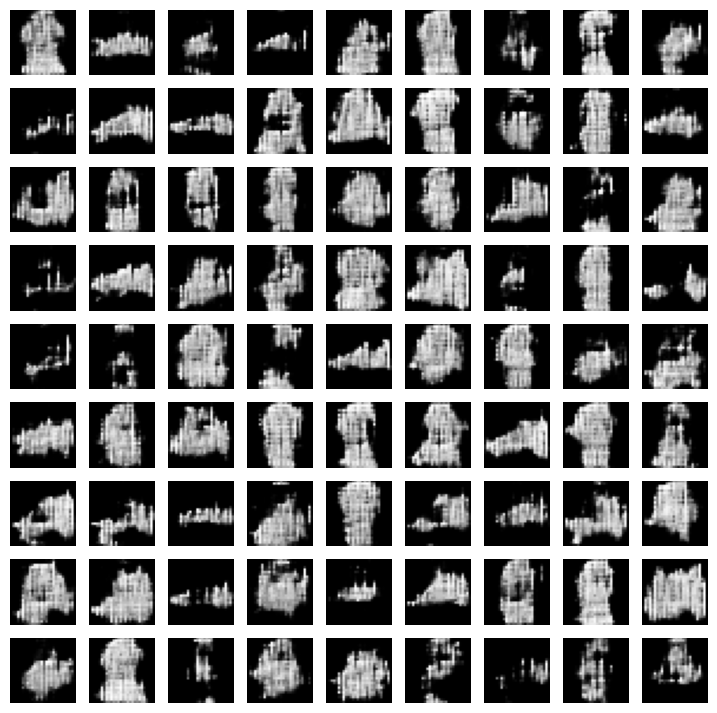

E:7, Loss G:1.7895, Loss D:0.3202, Acc G:%3.86, Acc D:%92.88
E:8, Loss G:1.8148, Loss D:0.3105, Acc G:%4.26, Acc D:%92.32


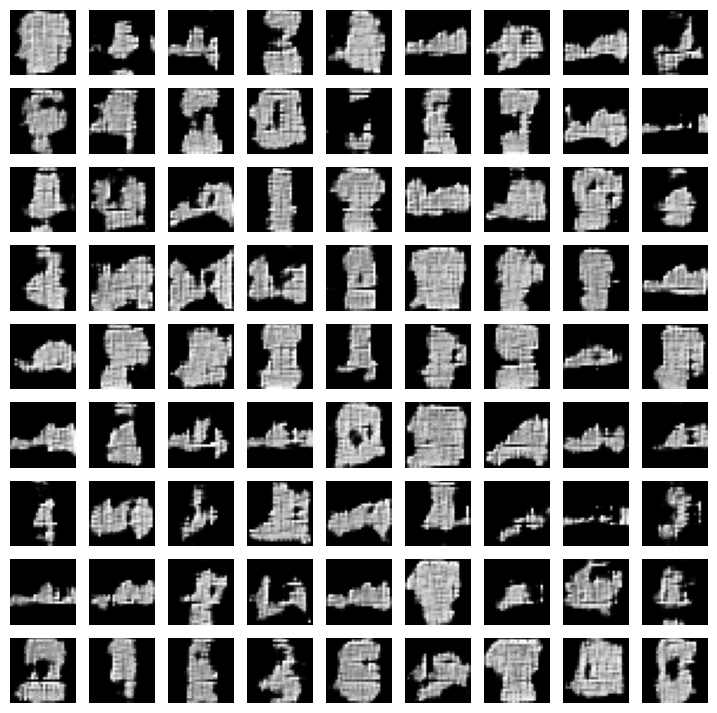

E:9, Loss G:1.8115, Loss D:0.3012, Acc G:%4.50, Acc D:%91.95
E:10, Loss G:1.8260, Loss D:0.2926, Acc G:%4.68, Acc D:%91.69


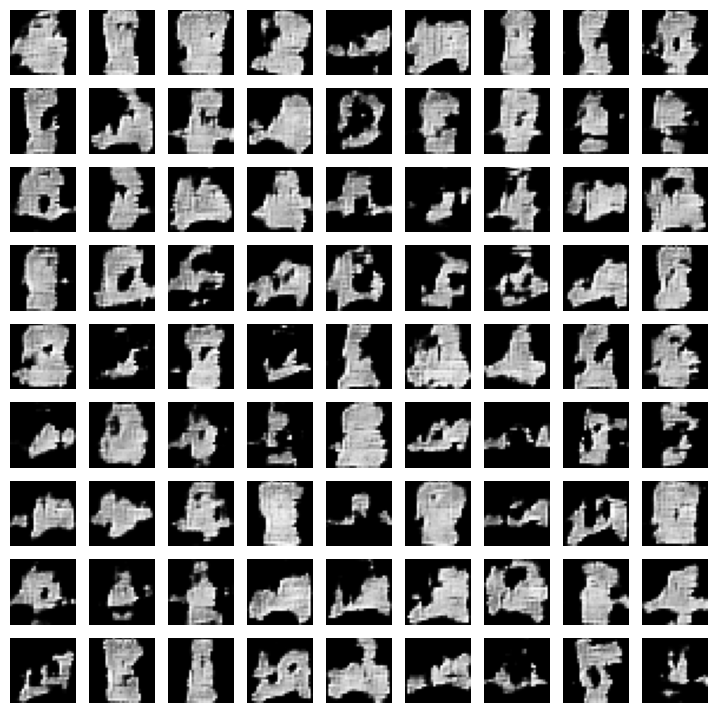

E:11, Loss G:1.8946, Loss D:0.2739, Acc G:%4.74, Acc D:%91.56
E:12, Loss G:1.9291, Loss D:0.2772, Acc G:%4.78, Acc D:%91.47


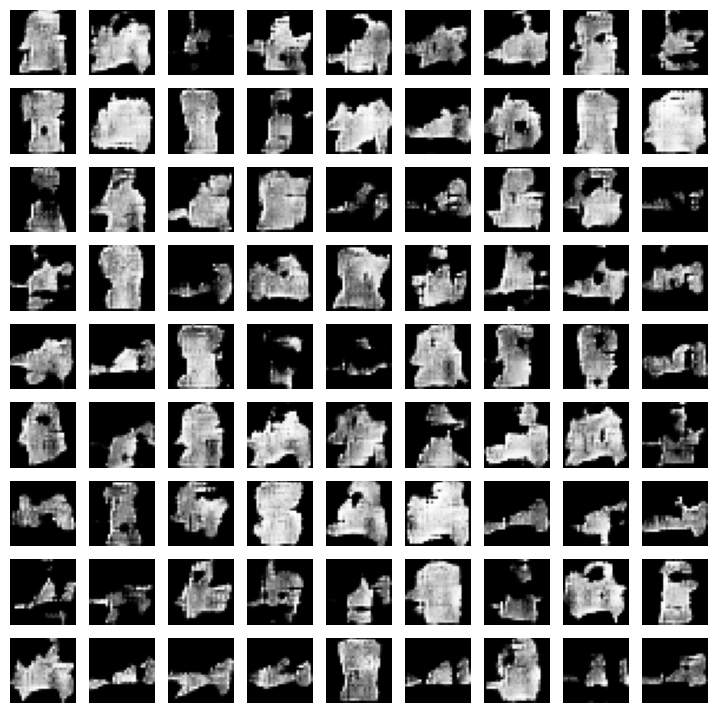

E:13, Loss G:1.9199, Loss D:0.3043, Acc G:%4.89, Acc D:%91.31
E:14, Loss G:1.9209, Loss D:0.3140, Acc G:%5.09, Acc D:%91.09


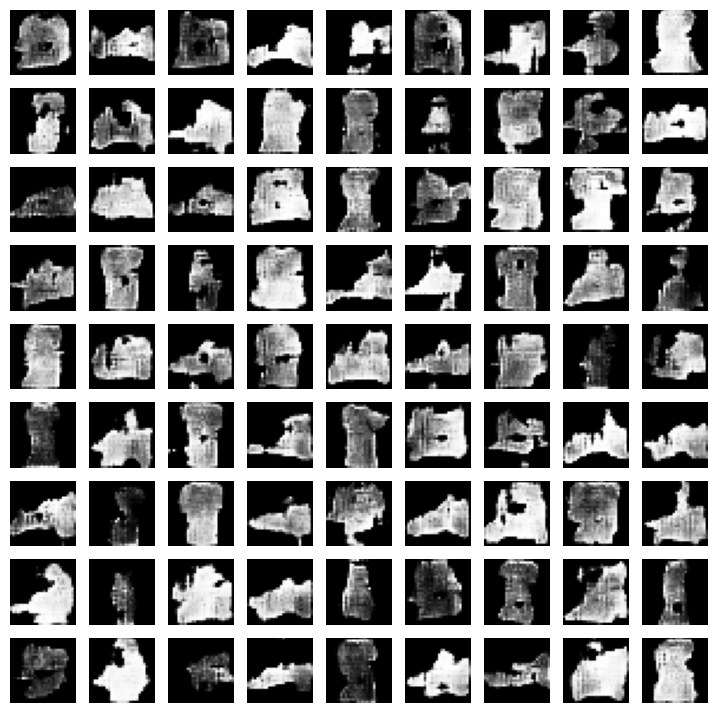

E:15, Loss G:1.9001, Loss D:0.3152, Acc G:%5.28, Acc D:%90.87
E:16, Loss G:1.9244, Loss D:0.3092, Acc G:%5.42, Acc D:%90.70


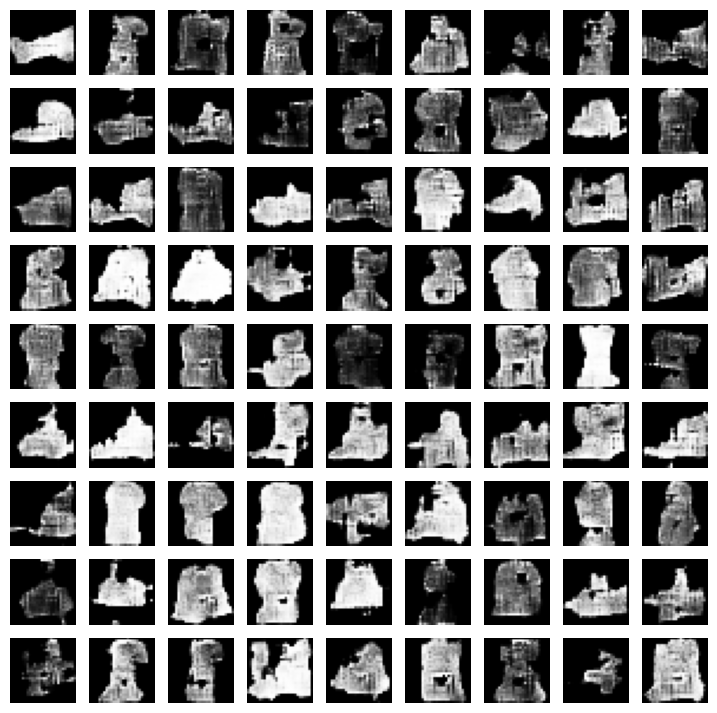

E:17, Loss G:1.9327, Loss D:0.3058, Acc G:%5.53, Acc D:%90.55
E:18, Loss G:1.9745, Loss D:0.2919, Acc G:%5.61, Acc D:%90.45


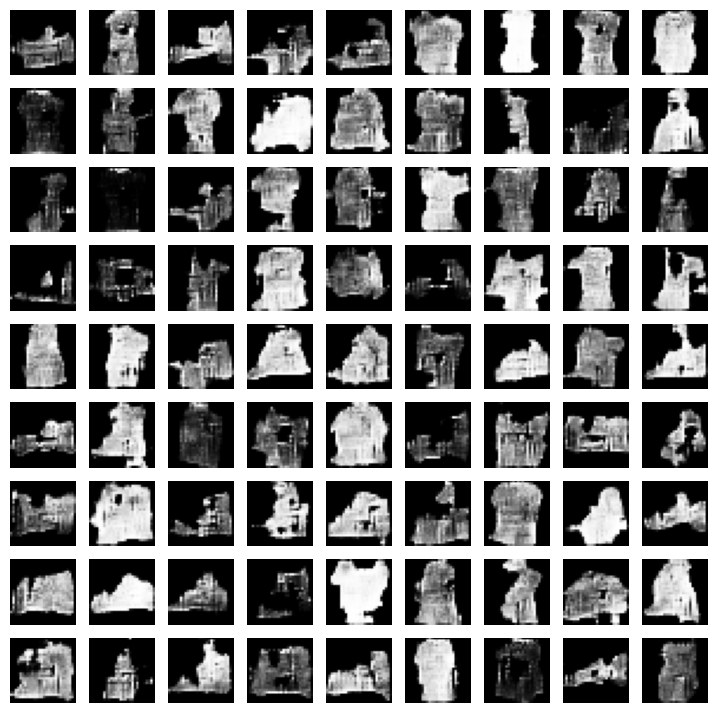

E:19, Loss G:1.9924, Loss D:0.2901, Acc G:%5.67, Acc D:%90.38
E:20, Loss G:2.0180, Loss D:0.2851, Acc G:%5.72, Acc D:%90.31


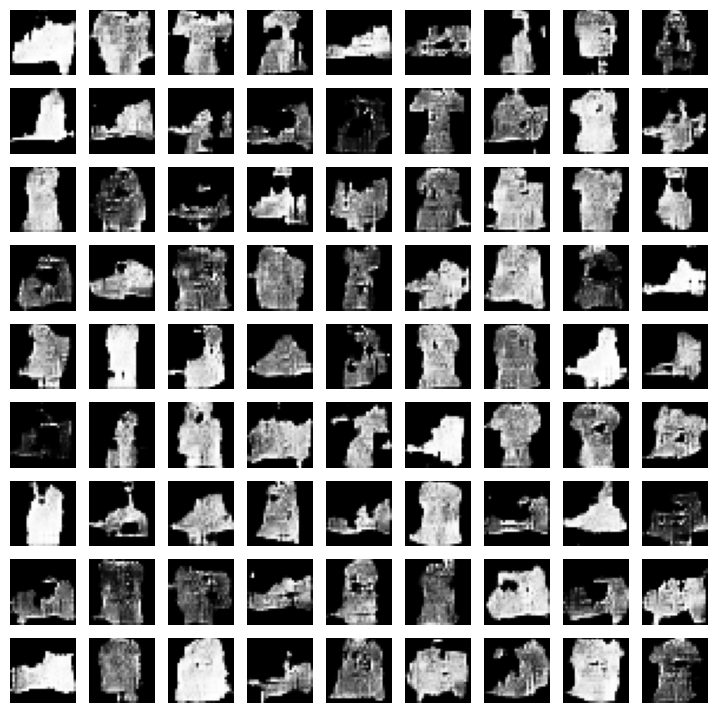

E:21, Loss G:2.0326, Loss D:0.2843, Acc G:%5.76, Acc D:%90.26
E:22, Loss G:2.0068, Loss D:0.2920, Acc G:%5.80, Acc D:%90.21


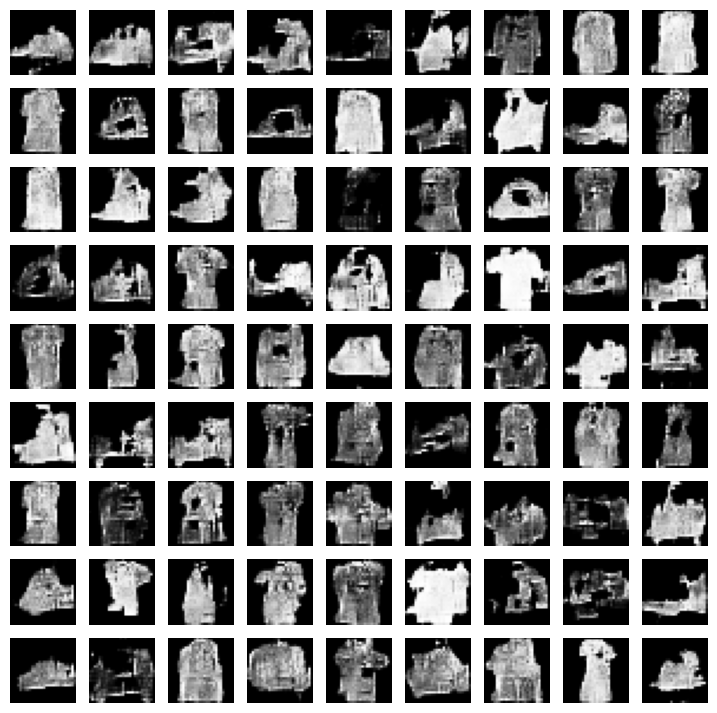

E:23, Loss G:1.9946, Loss D:0.2972, Acc G:%5.86, Acc D:%90.14
E:24, Loss G:1.9861, Loss D:0.2970, Acc G:%5.92, Acc D:%90.07


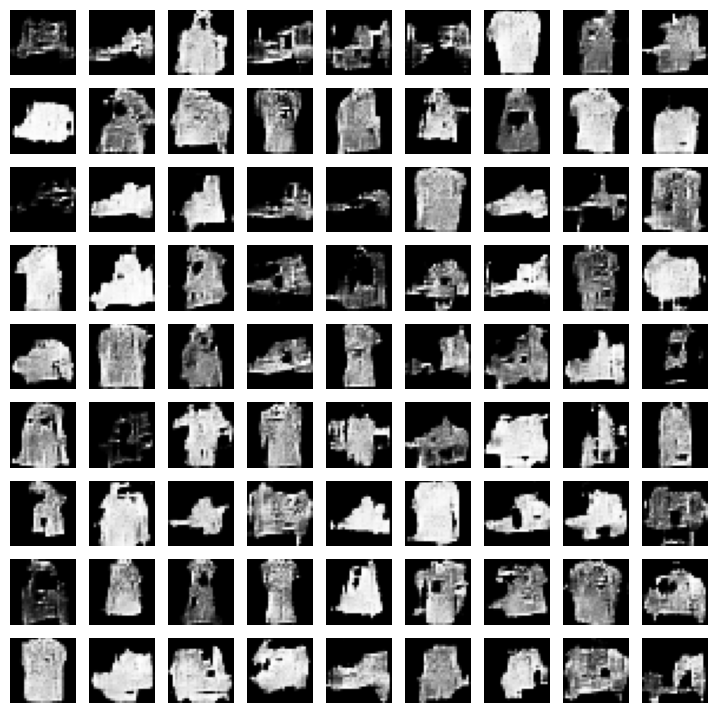

E:25, Loss G:1.9896, Loss D:0.2999, Acc G:%5.98, Acc D:%90.00
E:26, Loss G:1.9790, Loss D:0.3052, Acc G:%6.04, Acc D:%89.93


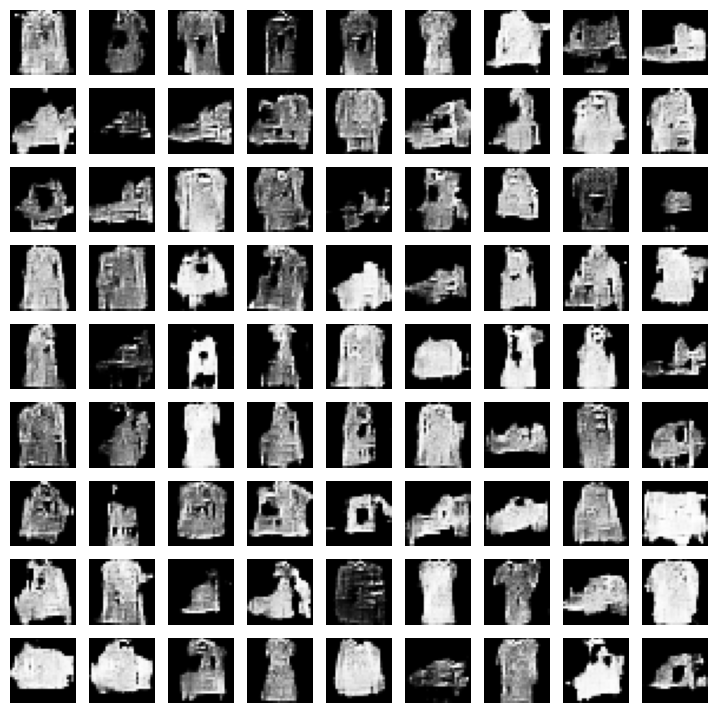

E:27, Loss G:1.9745, Loss D:0.3076, Acc G:%6.09, Acc D:%89.87
E:28, Loss G:1.9623, Loss D:0.3105, Acc G:%6.15, Acc D:%89.80


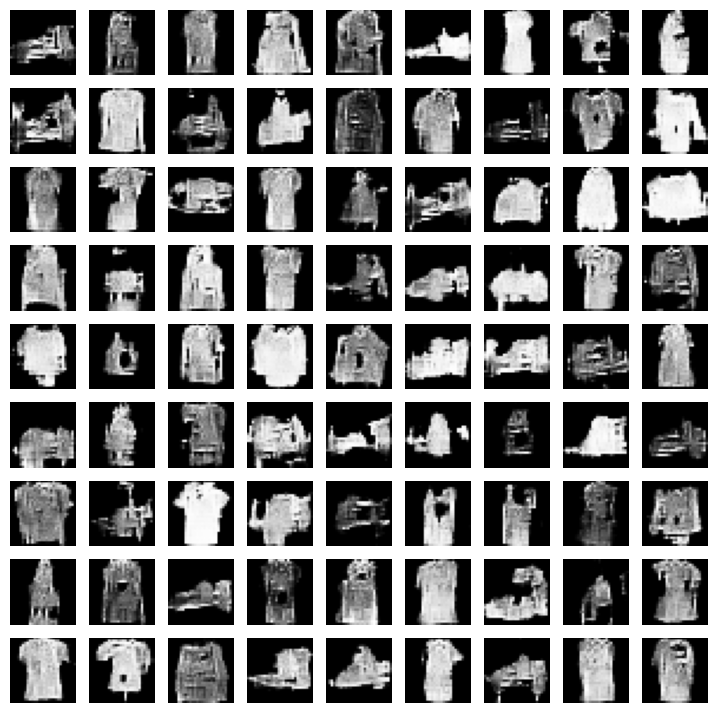

E:29, Loss G:1.9454, Loss D:0.3158, Acc G:%6.22, Acc D:%89.73


In [17]:
# fazendo o treinamento em loop
for epoch in range(30):

  # acumulando o loss para calcular a media a cada época
  dLossSum = 0
  gLossSum = 0
  dAccSum = 0
  gAccSum = 0
  cnt = 0

  # roda o dataset, um lote por vez
  for batch in dataset:

    # treina o discriminador
    dLoss = trainDStep(batch)
    dLossSum += dLoss['discriminator_loss']
    dAccSum += dLoss['discriminator_accuracy']

    # treina o gerador
    gLoss = trainGStep(batch)
    gLossSum += gLoss['generator_loss']
    gAccSum += gLoss['generator_accuracy']

    # incrementa o contador
    cnt += 1

  # log para as metricas
  print("E:{}, Loss G:{:0.4f}, Loss D:{:0.4f}, Acc G:%{:0.2f}, Acc D:%{:0.2f}".format(
      epoch,
      gLossSum/cnt,
      dLossSum/cnt,
      100 * gAccSum/cnt,
      100 * dAccSum/cnt
  ))

  # plota imagens a cada 2 épocas
  if epoch % 2 == 0:
    plotImages(generator)

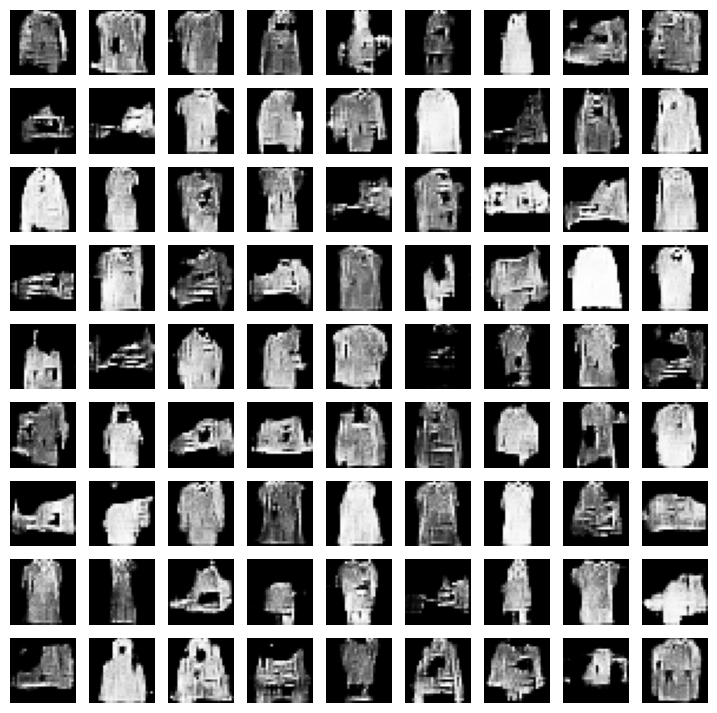

In [18]:
# criando uma imagem para teste
images = generator(np.random.normal(size=(81, NOISE_DIM)))

# plotando a imagem
plt.figure(figsize=(9, 9))

for i, image in enumerate(images):
    plt.subplot(9,9,i+1)
    plt.imshow(np.squeeze(image, -1), cmap="Greys_r")
    plt.axis('off')

plt.show();